<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_4_nested_cv_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Evolution of Model Evaluation: Why Nested Cross-Validation?

First, we told you to use a **Train/Test split**.
Then, we said, "Wait, use **Cross-Validation on the training data, plus a Test split**."
Now, we are talking about ditching the single test split entirely in favor of **Nested Cross-Validation**.

Why do we keep changing how we evaluate? The short answer: Hyperparameter tuning changes everything.

Let's walk through this progression using a concrete analogy:

**Studying for a Final Exam.** In this analogy:
* **Training Data** = Your textbook and homework.
* **Validation Data** = Practice exams.
* **Test Data** = The actual Final Exam.
* **Hyperparameter Tuning** = Changing your study strategy (e.g., trying flashcards vs. re-reading vs. group study) to see what gets you the best score on the practice exams.

## Stage 1: The Simple Train / Test Split
When we first learned Machine Learning, we split our data once.

**The Analogy:** You read the textbook (Train), and then you take the final exam (Test) to see how well you learned.

**The Problem:** What if you were just incredibly lucky? What if the 20% of data that ended up in the Test set happened to be the exact chapters you studied the hardest? Or what if it was the one chapter you skipped?

Because we only test *once*, our evaluation of the model is highly dependent on how the data was randomly split. We have high **variance** in our evaluation.

/tmp/ipykernel_4195/4281609076.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(idx % 6, idx // 6, c=plt.cm.tab20(idx / 20), s=200, marker='o', edgecolors='black', linewidth=1)
/tmp/ipykernel_4195/4281609076.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(idx % 6, idx // 6, c=plt.cm.tab20(idx / 20), s=200, marker='s', edgecolors='red', linewidth=3)


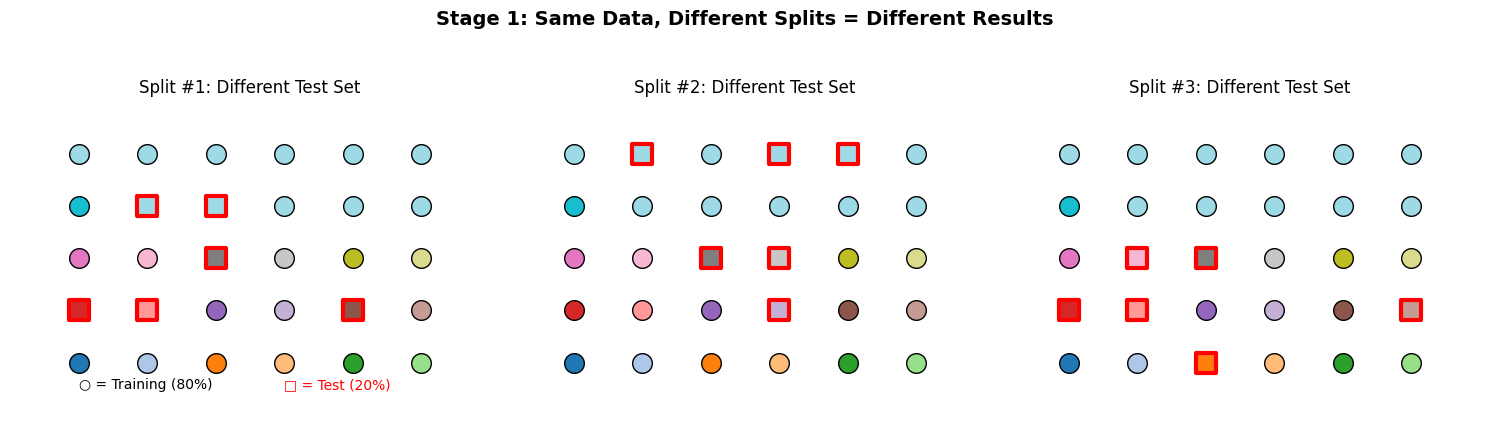

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_points = 30
# Create 30 "data points" - each has a unique ID shown by color
point_ids = np.arange(n_points)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    # Shuffle differently each time to simulate different random splits
    perm = np.random.permutation(n_points)
    train_idx = perm[:int(0.8 * n_points)]
    test_idx = perm[int(0.8 * n_points):]

    # Plot all points
    for idx in train_idx:
        ax.scatter(idx % 6, idx // 6, c=plt.cm.tab20(idx / 20), s=200, marker='o', edgecolors='black', linewidth=1)
    for idx in test_idx:
        ax.scatter(idx % 6, idx // 6, c=plt.cm.tab20(idx / 20), s=200, marker='s', edgecolors='red', linewidth=3)

    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 5)
    ax.set_title(f'Split #{i+1}: Different Test Set', fontsize=12)
    ax.axis('off')

    # Add legend
    if i == 0:
        ax.text(0, -0.5, '○ = Training (80%)', fontsize=10)
        ax.text(3, -0.5, '□ = Test (20%)', fontsize=10, color='red')

plt.suptitle('Stage 1: Same Data, Different Splits = Different Results', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Stage 2: Cross-Validation + Held-Out Test Set
To fix the "lucky/unlucky split" problem, we introduced K-Fold Cross Validation. But because we still need a final, unbiased evaluation, we lock away a Test set at the very beginning.

**The Analogy:** You lock the Final Exam (Test set) in a drawer. You use the textbook (Training Data), but you divide it into chapters. You study Chapter 1-4, and take a practice exam on Chapter 5. Then you study 2-5, and take a practice exam on Chapter 1.

Crucially, **this is where we do Hyperparameter Tuning.** We try different study strategies (Flashcards, Highlighting, etc.). We pick the strategy that gives us the highest *average* score across all the practice exams. Finally, we take the real Final Exam.

**The Problem:** This is actually a *great* approach if you have millions of rows of data. But if your dataset is smaller (e.g., 500 rows), we run into two massive problems:

1. **Wasted Data:** We locked 20% of our precious data in a drawer. The model never got to train on it before the final evaluation!
2. **Overfitting to the Validation Set:** If you tune 1,000 different combinations of hyperparameters, you are eventually going to find a combination that performs amazingly on the Cross-Validation folds purely by chance. You have inadvertently "peeked" at the validation data so many times that your model is biased toward it.
3. **The Unlucky Test Set Returns:** Because we tuned so heavily, the locked-away Test set is our *only* true measure of performance. But wait... what if that single Test set is an unlucky split? We are right back to the Stage 1 problem!

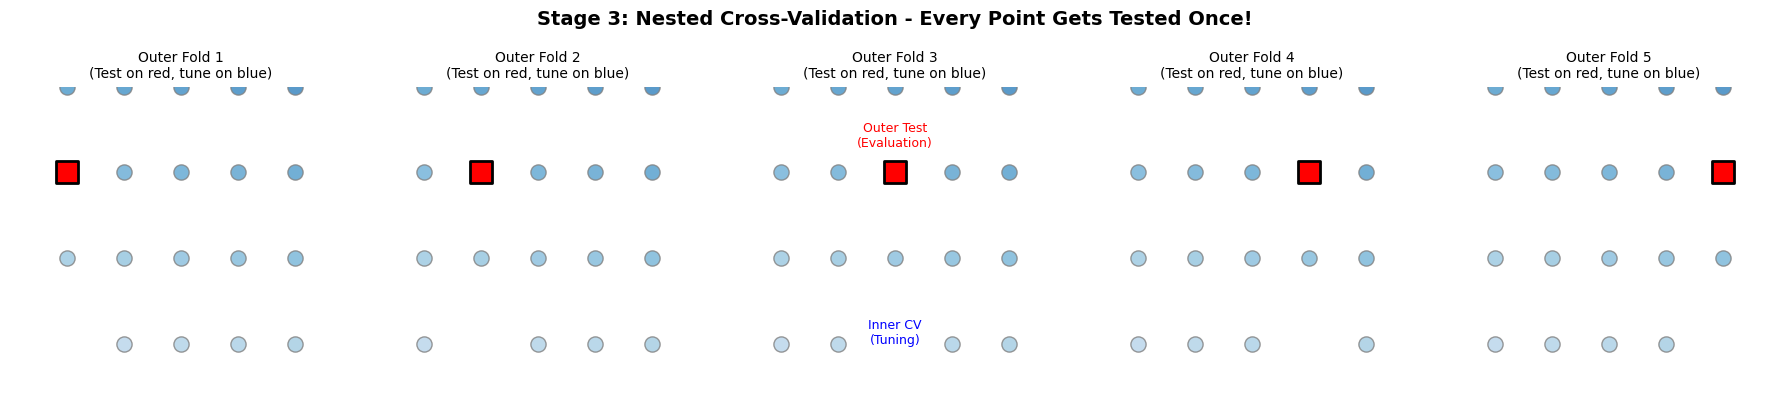

In [2]:
import matplotlib.patches as mpatches

np.random.seed(42)
n_points = 25  # Use 25 points so they divide nicely into 5 outer folds
point_ids = np.arange(n_points)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Create 5 outer folds
for fold_idx, ax in enumerate(axes):
    # Outer test fold: this fold's portion is the test set
    outer_test = [fold_idx]  # Single point as test
    # Inner loop training data: all other points
    inner_train = [i for i in range(n_points) if i != fold_idx]

    # Draw the outer test point (red square - the "final exam")
    ax.scatter(fold_idx % 5, 2, c='red', s=250, marker='s', edgecolors='black', linewidth=2, zorder=5)

    # Draw inner train points (lighter, for practice exams)
    inner_colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(inner_train)))
    for i, idx in enumerate(inner_train):
        ax.scatter(idx % 5, idx // 5, c=[inner_colors[i]], s=120, marker='o', edgecolors='gray', alpha=0.8)

    ax.set_xlim(-1, 5)
    ax.set_ylim(-0.5, 3)
    ax.set_title(f'Outer Fold {fold_idx+1}\n(Test on red, tune on blue)', fontsize=10)
    ax.axis('off')

    # Add annotation
    if fold_idx == 2:
        ax.annotate('Inner CV\n(Tuning)', xy=(2, 0), fontsize=9, ha='center', color='blue')
        ax.annotate('Outer Test\n(Evaluation)', xy=(2, 2.3), fontsize=9, ha='center', color='red')

plt.suptitle('Stage 3: Nested Cross-Validation - Every Point Gets Tested Once!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 2: Cross-Validation + Held-Out Test Set

/tmp/ipykernel_4195/3086380150.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(idx % 4 + 0.5, y_pos - 0.2, c=color, s=150, marker='s', edgecolors='black', linewidth=2)


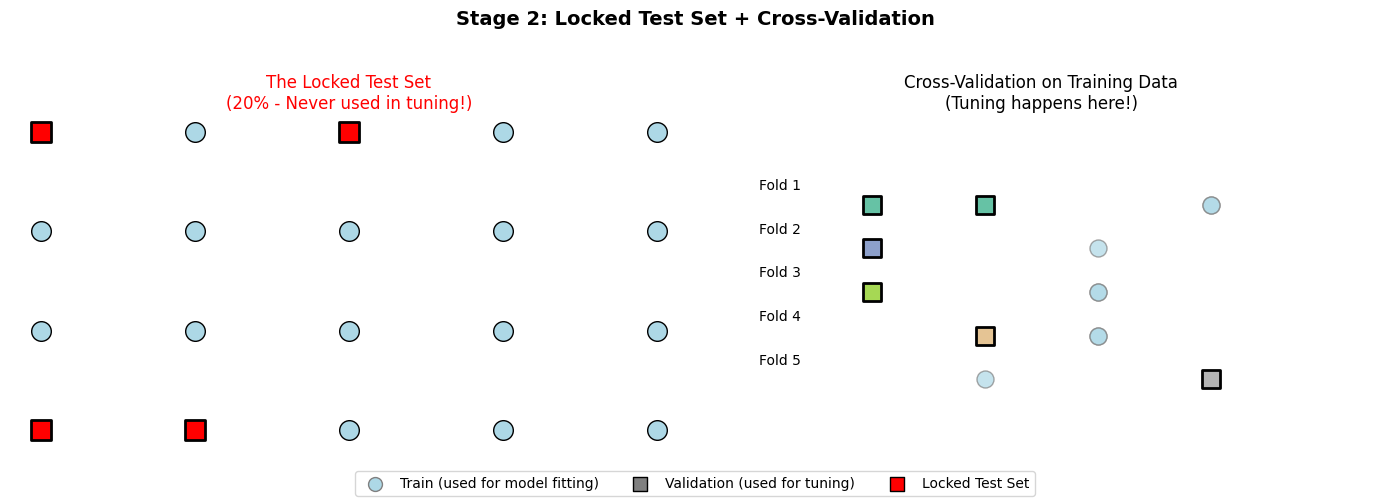

In [3]:
np.random.seed(42)
n_points = 20
point_ids = np.arange(n_points)
# Create a figure with two parts: locked test set + CV on training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: The locked test set (permanently held out)
test_locked = np.random.choice(n_points, int(0.2 * n_points), replace=False)
train_set = [i for i in range(n_points) if i not in test_locked]

for idx in train_set:
    ax1.scatter(idx % 5, idx // 5, c='lightblue', s=200, marker='o', edgecolors='black')
for idx in test_locked:
    ax1.scatter(idx % 5, idx // 5, c='red', s=200, marker='s', edgecolors='black', linewidth=2)

ax1.set_title('The Locked Test Set\n(20% - Never used in tuning!)', fontsize=12, color='red')
ax1.axis('off')

# RIGHT: 5-fold CV on the training portion
n_folds = 5
train_array = np.array(train_set)
np.random.shuffle(train_array)
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
colors = plt.cm.Set2(np.linspace(0, 1, n_folds))

y_positions = [3, 2.4, 1.8, 1.2, 0.6]
for fold_idx, (y_pos, color) in enumerate(zip(y_positions, colors)):
    # Split this fold's training data into train/val
    fold_data = train_array[fold_idx::n_folds]  # every nth element
    val_size = len(fold_data) // 2
    val_data = fold_data[:val_size]
    train_data = fold_data[val_size:]

    # Draw horizontal bar
    for idx in train_data:
        ax2.scatter(idx % 4 + 0.5, y_pos - 0.2, c='lightblue', s=150, marker='o', edgecolors='gray', alpha=0.7)
    for idx in val_data:
        ax2.scatter(idx % 4 + 0.5, y_pos - 0.2, c=color, s=150, marker='s', edgecolors='black', linewidth=2)

    ax2.text(-0.5, y_pos, f'Fold {fold_idx+1}', fontsize=10)

ax2.set_title('Cross-Validation on Training Data\n(Tuning happens here!)', fontsize=12)
ax2.set_xlim(-1, 5)
ax2.set_ylim(-0.5, 4)
ax2.axis('off')

# Legend
plt.figlegend([plt.scatter([], [], c='lightblue', s=100, marker='o', edgecolors='gray'),
               plt.scatter([], [], c='gray', s=100, marker='s', edgecolors='black'),
               plt.scatter([], [], c='red', s=100, marker='s', edgecolors='black')],
              ['Train (used for model fitting)', 'Validation (used for tuning)', 'Locked Test Set'],
              loc='lower center', ncol=3, frameon=True)

plt.suptitle('Stage 2: Locked Test Set + Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Stage 2: Cross-Validation + Held-Out Test Set
To fix the "lucky/unlucky split" problem, we introduced K-Fold Cross Validation. But because we still need a final, unbiased evaluation, we lock away a Test set at the very beginning.

**The Analogy:** You lock the Final Exam (Test set) in a drawer. You use the textbook (Training Data), but you divide it into chapters. You study Chapter 1-4, and take a practice exam on Chapter 5. Then you study 2-5, and take a practice exam on Chapter 1.

Crucially, **this is where we do Hyperparameter Tuning.** We try different study strategies (Flashcards, Highlighting, etc.). We pick the strategy that gives us the highest *average* score across all the practice exams. Finally, we take the real Final Exam.

**The Problem:** This is actually a *great* approach if you have millions of rows of data. But if your dataset is smaller (e.g., 500 rows), we run into two massive problems:

1. **Wasted Data:** We locked 20% of our precious data in a drawer. The model never got to train on it before the final evaluation!
2. **Overfitting to the Validation Set:** If you tune 1,000 different combinations of hyperparameters, you are eventually going to find a combination that performs amazingly on the Cross-Validation folds purely by chance. You have inadvertently "peeked" at the validation data so many times that your model is biased toward it.
3. **The Unlucky Test Set Returns:** Because we tuned so heavily, the locked-away Test set is our *only* true measure of performance. But wait... what if that single Test set is an unlucky split? We are right back to the Stage 1 problem!

## Stage 3: Nested Cross-Validation (The Ultimate Solution)
How do we evaluate a heavily-tuned model without locking away 20% of our data forever? **Nested Cross Validation.**

Instead of having a single Test set, we use Cross-Validation to create our Test sets (the **Outer Loop**), and *inside* of that, we use Cross-Validation again to tune our hyperparameters (the **Inner Loop**).

**The Analogy:**
You have 5 different Final Exams.
For Final Exam #1, you use the remaining material to run practice tests, find your best study strategy, and then take Final Exam #1.
Then, you wipe your memory.
For Final Exam #2, you use the *other* material to run practice tests, find your best study strategy (it might be a different strategy this time!), and then take Final Exam #2.

### Why is this so powerful?
Notice what happens in Nested CV: **Every single data point gets to be in a Test set exactly once.**

We are no longer evaluating a *single model*. We are evaluating our **Model Building Process**. We are proving: "If I take a subset of data, tune hyperparameters, and test it on unseen data, how well does that overall process work on average?"

Once we prove the *process* works via Nested CV, we can confidently train one final model on **100% of our data**, tuning the hyperparameters one last time, and deploy it to the real world.

Let's look at how incredibly simple this is to code in `scikit-learn`.

In [4]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

# Load a relatively small dataset
X, y = load_breast_cancer(return_X_y=True)

# Define our model and the hyperparameters we want to tune
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

# ---------------------------------------------------------
# STAGE 2: Standard CV + Test Split (What we used to do)
# ---------------------------------------------------------
# We define an Inner CV for hyperparameter tuning.
# If we stopped here, we'd have to use train_test_split first and
# lock away some data to evaluate this GridSearchCV.
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

clf = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv)

# ---------------------------------------------------------
# STAGE 3: NESTED CV (The Magic Trick)
# ---------------------------------------------------------
# We define an Outer CV for evaluating the entire tuning process.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# THE MAGIC: We pass the GridSearchCV object (which contains the inner CV)
# into cross_val_score (which acts as the outer CV).
# Scikit-learn automatically handles the nested looping!
nested_scores = cross_val_score(clf, X=X, y=y, cv=outer_cv)

print("Nested CV Scores for each Outer Fold:")
for i, score in enumerate(nested_scores):
    print(f"Outer Fold {i+1}: {score:.4f}")

print(f"\nUnbiased Estimate of Model Performance: {nested_scores.mean():.4f} (+/- {nested_scores.std():.4f})")

Nested CV Scores for each Outer Fold:
Outer Fold 1: 0.9561
Outer Fold 2: 0.9649
Outer Fold 3: 0.9386
Outer Fold 4: 0.9649
Outer Fold 5: 0.9646

Unbiased Estimate of Model Performance: 0.9578 (+/- 0.0102)


### Summary: When to use what?

1. **Train/Test Split:** Use for very quick and dirty baselines, or if you have an absolutely massive dataset (Millions of rows) where "lucky splits" are statistically impossible.
2. **CV + Held-out Test Set:** Use when you have a medium-to-large dataset, and you are only doing light hyperparameter tuning.
3. **Nested CV:** Use when you have a small dataset (e.g., medical data, thousands of rows or less) AND you are testing many different models or doing heavy hyperparameter tuning. It prevents data leakage and ensures your final performance metric is mathematically sound.